In [0]:
pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.7/767.7 kB 24.0 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.10.0
    Not uninstalling typing-extensions at /databricks/python3/lib/python3.11/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-770924e4-b5b9-4aba-bce8-5c5d54cff64d
    Can't uninstall 'typing_extensions'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
import random
import string

# Simulate normal plates
def generate_license_plates(n=1000):
    plates = []
    for _ in range(n):
        part1 = ''.join(random.choices(string.ascii_uppercase, k=random.randint(2, 3)))
        part2 = ''.join(random.choices(string.digits, k=random.randint(2, 4)))
        plates.append(random.choice([part1 + part2, part2 + part1]))
    return plates

# Offensive examples for testing quality
offensive_plates = [
    "SEXYY69", "DRUGLORD", "K1LLALL", "FCKYOU", "420BLAZE", "WHTPWR", "KKKMAN", "HITLER1"
]

all_plates = generate_license_plates() + offensive_plates
random.shuffle(all_plates)


In [0]:
len(all_plates)

1008

In [0]:
import openai
import time
from dotenv import load_dotenv

load_dotenv()
open_api= os.getenv("open_api")
openai.api_key = open_api

def build_batch_prompt(plates):
    header = """
Classify the following license plates as either 'Accept' or 'Reject'. If Reject, provide the reason based on:
- Sexual references
- Discrimination or hate speech
- Unclear for law enforcement
- Abusive, obscene language and derogatory slang
- Religion
- Drugs/alcohol
- Political figures
- Dignitaries/law enforcement officials
- Violence/criminal activity
- Human rights discrimination
- Clarity/readability for law enforcement
- Objectionable graphics/character combinations
---
Format: <Plate> - <Accept/Reject> - <Reason if Reject>
"""
    body = "\n".join([f"{i+1}. {plate}" for i, plate in enumerate(plates)])
    return header + "\n" + body

In [0]:
import time
import pandas as pd
import mlflow

batch_sizes_to_test = [100, 200, 400, 600, 800]
all_batch_data_even = []
all_results_summary_even = []

for batch_size in batch_sizes_to_test:
    print(f"\n=== Processing batch size: {batch_size} ===")

    full_batches = len(all_plates) // batch_size
    batch_metrics = []  # Stores per-batch stats

    for batch_index in range(full_batches):
        start_idx = batch_index * batch_size
        end_idx = start_idx + batch_size
        batch = all_plates[start_idx:end_idx]
        prompt = build_batch_prompt(batch)

        start = time.time()
        try:
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                temperature=0
            )
            reply = response.choices[0].message.content
            usage = response.usage
            prompt_tokens = usage.prompt_tokens
            completion_tokens = usage.completion_tokens
            total_tokens = usage.total_tokens
            errors = 0

            # Cost calculation
            cost_prompt = (prompt_tokens / 1000) * 0.0015
            cost_completion = (completion_tokens / 1000) * 0.002
            total_cost = cost_prompt + cost_completion

        except Exception as e:
            print(f"  Error on batch {batch_index + 1}: {str(e)}")
            reply = None
            prompt_tokens = 0
            completion_tokens = 0
            total_tokens = 0
            cost_prompt = 0
            cost_completion = 0
            total_cost = 0
            errors = 1
            time.sleep(10)

        end = time.time()
        time_taken = end - start
        plates_per_sec = batch_size / time_taken if time_taken > 0 else 0

        # Store per-batch metrics
        batch_metrics.append({
            "batch_index": batch_index + 1,
            "batch_size": batch_size,
            "plates_processed": batch_size,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "time_taken": time_taken,
            "plates_per_sec": plates_per_sec,
            "throughput": plates_per_sec,
            "errors": errors,
            "reply": reply,
            "cost_prompt": cost_prompt,
            "cost_completion": cost_completion,
            "total_cost": total_cost,
            "cost_per_1k_tokens": (total_cost / (total_tokens / 1000)) if total_tokens else 0,
            "cost_per_1000_plates": (total_cost / batch_size) * 1000 if batch_size else 0
        })

    # Summarize for current batch size
    total_plates = sum(b["plates_processed"] for b in batch_metrics)
    total_time = sum(b["time_taken"] for b in batch_metrics)
    total_prompt_tokens = sum(b["prompt_tokens"] for b in batch_metrics)
    total_completion_tokens = sum(b["completion_tokens"] for b in batch_metrics)
    total_tokens = sum(b["total_tokens"] for b in batch_metrics)
    total_cost = sum(b["total_cost"] for b in batch_metrics)
    total_errors = sum(b["errors"] for b in batch_metrics)
    throughput = total_plates / total_time if total_time > 0 else 0
    cost_per_1000_plates = (total_cost / total_plates) * 1000 if total_plates else 0

    all_batch_data_even.append({
        "batch_size": batch_size,
        "batch_metrics": batch_metrics
    })

    all_results_summary_even.append({
        "batch_size": batch_size,
        "plates_processed": total_plates,
        "total_time": total_time,
        "throughput": throughput,
        "prompt_tokens": total_prompt_tokens,
        "completion_tokens": total_completion_tokens,
        "total_tokens": total_tokens,
        "cost": total_cost,
        "cost_per_1000_plates": cost_per_1000_plates,
        "errors": total_errors
    })

    # Process replies to flag
    results = []
    for entry in batch_metrics:
        reply = entry["reply"]
        if reply:
            for line in reply.splitlines():
                results.append(line.strip())

    df = pd.DataFrame(results, columns=["LLM Classification"])
    flagged = df[df["LLM Classification"].str.contains("Reject", case=False)]

    # Print summary
    print(f"\n=== Summary for batch size {batch_size} ===")
    print(f" Plates processed: {total_plates}")
    print(f" Time: {total_time:.2f} seconds")
    print(f" Throughput: {throughput:.2f} plates/sec")
    print(f" Prompt tokens: {total_prompt_tokens}")
    print(f" Completion tokens: {total_completion_tokens}")
    print(f" Total tokens: {total_tokens}")
    print(f" Cost: ${total_cost:.4f}")
    print(f" Cost per 1,000 plates: ${cost_per_1000_plates:.4f}")
    print(f" Errors: {total_errors}")
    if not flagged.empty:
        print(" Flagged results:")
        display(flagged)



# MLflow logging (optional)
# username = dbutils.notebook.entry_point.getDbutils().notebook().getContext().userName().get()
# mlflow.set_experiment(f"/Users/{username}/llm_plate_classification")
# for result in all_results_summary:
#     with mlflow.start_run(run_name=f"batch_{result['batch_size']}"):
#         for key, value in result.items():
#             mlflow.log_metric(key, value)



=== Processing batch size: 100 ===

=== Summary for batch size 100 ===
 Plates processed: 1000
 Time: 98.01 seconds
 Throughput: 10.20 plates/sec
 Prompt tokens: 7688
 Completion tokens: 8433
 Total tokens: 16121
 Cost: $0.0284
 Cost per 1,000 plates: $0.0284
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"19. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
65. SEXYY69 - Reject - Sexual references
67. K1LLALL - Reject - Violence/criminal activity
86. DRUGLORD - Reject - Drugs/alcohol
19. HITLER1 - Reject - Human rights discrimination
87. KKKMAN - Reject - Discrimination or hate speech
5. FI69 - Reject - Sexual references
11. 69GZ - Reject - Sexual references
78. 385FI - Reject - Sexual references



=== Processing batch size: 200 ===

=== Summary for batch size 200 ===
 Plates processed: 1000
 Time: 107.43 seconds
 Throughput: 9.31 plates/sec
 Prompt tokens: 7043
 Completion tokens: 8435
 Total tokens: 15478
 Cost: $0.0274
 Cost per 1,000 plates: $0.0274
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"19. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
65. SEXYY69 - Reject - Sexual references
67. K1LLALL - Reject - Violence/criminal activity
86. DRUGLORD - Reject - Drugs/alcohol
119. HITLER1 - Reject - Human rights discrimination
187. KKKMAN - Reject - Discrimination or hate speech
5. FI69 - Reject - Sexual references
11. 69GZ - Reject - Sexual references



=== Processing batch size: 400 ===

=== Summary for batch size 400 ===
 Plates processed: 800
 Time: 76.12 seconds
 Throughput: 10.51 plates/sec
 Prompt tokens: 5389
 Completion tokens: 4264
 Total tokens: 9653
 Cost: $0.0166
 Cost per 1,000 plates: $0.0208
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
86. DRUGLORD - Reject - Drugs/alcohol
119. HITLER1 - Reject - Human rights discrimination
187. KKKMAN - Reject - Discrimination or hate speech



=== Processing batch size: 600 ===

=== Summary for batch size 600 ===
 Plates processed: 600
 Time: 38.08 seconds
 Throughput: 15.76 plates/sec
 Prompt tokens: 3977
 Completion tokens: 4096
 Total tokens: 8073
 Cost: $0.0142
 Cost per 1,000 plates: $0.0236
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"219. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
265. SEXYY69 - Reject - Sexual references
267. K1LLALL - Reject - Violence/criminal activity



=== Processing batch size: 800 ===

=== Summary for batch size 800 ===
 Plates processed: 800
 Time: 74.06 seconds
 Throughput: 10.80 plates/sec
 Prompt tokens: 5260
 Completion tokens: 4096
 Total tokens: 9356
 Cost: $0.0161
 Cost per 1,000 plates: $0.0201
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"219. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
265. SEXYY69 - Reject - Sexual references
267. K1LLALL - Reject - Violence/criminal activity
445. WHTPWR - Reject - Objectionable graphics/character combinations


In [0]:
# Convert to DataFrame
summary_df_even = pd.DataFrame(all_results_summary_even)
detailed_df_even = pd.concat([pd.DataFrame(batch["batch_metrics"]) for batch in all_batch_data_even], ignore_index=True)

print("\n=== Summary Table ===")
display(summary_df_even)
display(detailed_df_even)


=== Summary Table ===


batch_size,plates_processed,total_time,throughput,prompt_tokens,completion_tokens,total_tokens,cost,cost_per_1000_plates,errors
100,1000,98.01038122177124,10.203000820262783,7688,8433,16121,0.028398000000000003,0.028398000000000003,0
200,1000,107.43068504333496,9.308327500626325,7043,8435,15478,0.0274345,0.0274345,0
400,800,76.12457227706909,10.509090246027997,5389,4264,9653,0.0166115,0.020764375,0
600,600,38.0775945186615,15.75729789616687,3977,4096,8073,0.0141575,0.023595833333333333,0
800,800,74.06488847732544,10.80133942610223,5260,4096,9356,0.016082,0.0201025,0


batch_index,batch_size,plates_processed,prompt_tokens,completion_tokens,total_tokens,time_taken,plates_per_sec,throughput,errors,reply,cost_prompt,cost_completion,total_cost,cost_per_1k_tokens,cost_per_1000_plates
1,100,100,780,854,1634,15.160329341888428,6.596162770929858,6.596162770929858,0,1. EAA2536 - Accept 2. 1498ZOO - Accept 3. VDL7178 - Accept 4. VN184 - Accept 5. 9385PNE - Accept 6. IL8731 - Accept 7. GO033 - Accept 8. 7452QC - Accept 9. TIT296 - Accept 10. 12JS - Accept 11. 14VEQ - Accept 12. HCV72 - Accept 13. 718EJU - Accept 14. CD4525 - Accept 15. 670UDS - Accept 16. 484PT - Accept 17. KY9205 - Accept 18. AK92 - Accept 19. JG12 - Accept 20. LD95 - Accept 21. WLF71 - Accept 22. OTZ92 - Accept 23. RH88 - Accept 24. TV0008 - Accept 25. DH043 - Accept 26. 955JPS - Accept 27. UE801 - Accept 28. JA17 - Accept 29. 6240WJH - Accept 30. 913YO - Accept 31. 614ER - Accept 32. ZSK52 - Accept 33. VE14 - Accept 34. 782IZ - Accept 35. IF67 - Accept 36. KJI00 - Accept 37. GIH094 - Accept 38. XC4399 - Accept 39. 92JY - Accept 40. FQJ140 - Accept 41. UOG7943 - Accept 42. 15XTV - Accept 43. SVW22 - Accept 44. 9059YYH - Accept 45. 367RV - Accept 46. UBW2635 - Accept 47. 9148DHQ - Accept 48. 1213SEP - Accept 49. 0008TPW - Accept 50. 4651SY - Accept 51. PH751 - Accept 52. 42ZJ - Accept 53. 70YP - Accept 54. 251ZKR - Accept 55. RQ975 - Accept 56. 0009NFG - Accept 57. CC62 - Accept 58. GL78 - Accept 59. 2998THN - Accept 60. OL993 - Accept 61. 1626LVV - Accept 62. 53RLG - Accept 63. ION9898 - Accept 64. 268BCH - Accept 65. GL6308 - Accept 66. FD85 - Accept 67. SQ457 - Accept 68. 5422HQ - Accept 69. 4560GTN - Accept 70. OLF52 - Accept 71. LJT11 - Accept 72. 5302EHE - Accept 73. 633CQ - Accept 74. 41FZP - Accept 75. 110WFU - Accept 76. 305XDI - Accept 77. 70YYK - Accept 78. UT68 - Accept 79. 58WI - Accept 80. 26HJ - Accept 81. JMU3906 - Accept 82. 6025OD - Accept 83. 6478YLU - Accept 84. GCP912 - Accept 85. VD8226 - Accept 86. FM4775 - Accept 87. XFC0969 - Accept 88. 7790QN - Accept 89. 9049NYY - Accept 90. 58BJQ - Accept 91. 0871FF - Accept 92. GCA85 - Accept 93. CSB96 - Accept 94. SBM45 - Accept 95. WIW3985 - Accept 96. 2872ZJ - Accept 97. 2616IWH - Accept 98. UFM380 - Accept 99. 420BLAZE - Reject - Drugs/alcohol 100. PY4742 - Accept,0.00117,0.001708,0.0028780000000000003,0.001761321909424725,0.028780000000000003
2,100,100,754,824,1578,12.615096092224121,7.927010564877066,7.927010564877066,0,1. QQ694 - Accept 2. YQN15 - Accept 3. 3253KRI - Accept 4. ODW58 - Accept 5. 68FGZ - Accept 6. OWS10 - Accept 7. 697NO - Accept 8. OSO31 - Accept 9. 259TUI - Accept 10. 776TD - Accept 11. LCG77 - Accept 12. 72CK - Accept 13. IY435 - Accept 14. 957UB - Accept 15. 419RS - Accept 16. 641ZW - Accept 17. 19JP - Accept 18. YKT20 - Accept 19. LSF41 - Accept 20. 99JDK - Accept 21. 709WF - Accept 22. UE09 - Accept 23. MM212 - Accept 24. TGS70 - Accept 25. 4186IK - Accept 26. 32BC - Accept 27. TK103 - Accept 28. 509AB - Accept 29. QAD3453 - Accept 30. RWO26 - Accept 31. PTQ1244 - Accept 32. WIQ0313 - Accept 33. 894DE - Accept 34. ZSC90 - Accept 35. 669ZL - Accept 36. 7089CW - Accept 37. VBS0439 - Accept 38. 25SHE - Accept 39. 11JCX - Accept 40. VX84 - Accept 41. 99NZI - Accept 42. UW852 - Accept 43. GN95 - Accept 44. XV20 - Accept 45. 18UCB - Accept 46. 51AGG - Accept 47. 837MUE - Accept 48. BM363 - Accept 49. ONL74 - Accept 50. XI0357 - Accept 51. JKF574 - Accept 52. 102CF - Accept 53. 4681NR - Accept 54. 2430RTO - Accept 55. COR109 - Accept 56. 0226XLD - Accept 57. 06CET - Accept 58. GJ93 - Accept 59. SSW90 - Accept 60. 4505WY - Accept 61. SEE8818 - Accept 62. JJC031 - Accept 63. 9965QQ - Accept 64. HYB75 - Accept 65. DY758 - Accept 66. 49TXD - Accept 67. 00QCJ - Accept 68. RR941 - Accept 69. JY351 - Accept 70. JCX12 - Accept 71. 2793ZU - Accept 72. WG361 - Accept 73. YYJ018 - Accept 74. 914DLR - Accept 75. 37IP - Accept 76. 498SE - Accept 77. 54HSS - Accept 78. ZT630 - Accept 79. UY259 - Accept 80. AJ3220 - Accept 81. BP993 - Accept 82. 4375ZP - Accept 83. 3

In [0]:
import time
import pandas as pd
import mlflow

batch_sizes_to_test_odd = [300, 500, 700, 900]
all_batch_data_odd = []
all_results_summary_odd = []

for batch_size in batch_sizes_to_test_odd:
    print(f"\n=== Processing batch size: {batch_size} ===")

    full_batches = len(all_plates) // batch_size
    batch_metrics = []  # Stores per-batch stats

    for batch_index in range(full_batches):
        start_idx = batch_index * batch_size
        end_idx = start_idx + batch_size
        batch = all_plates[start_idx:end_idx]
        prompt = build_batch_prompt(batch)

        start = time.time()
        try:
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                temperature=0
            )
            reply = response.choices[0].message.content
            usage = response.usage
            prompt_tokens = usage.prompt_tokens
            completion_tokens = usage.completion_tokens
            total_tokens = usage.total_tokens
            errors = 0
            # Cost calculation
            cost_prompt = (prompt_tokens / 1000) * 0.0015
            cost_completion = (completion_tokens / 1000) * 0.002
            total_cost = cost_prompt + cost_completion

        except Exception as e:
            print(f"  Error on batch {batch_index + 1}: {str(e)}")
            reply = None
            prompt_tokens = 0
            completion_tokens = 0
            total_tokens = 0
            cost_prompt = 0
            cost_completion = 0
            total_cost = 0
            errors = 1
            time.sleep(10)

        end = time.time()
        time_taken = end - start
        plates_per_sec = batch_size / time_taken if time_taken > 0 else 0

        # Store per-batch metrics
        batch_metrics.append({
            "batch_index": batch_index + 1,
            "batch_size": batch_size,
            "plates_processed": batch_size,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "time_taken": time_taken,
            "plates_per_sec": plates_per_sec,
            "throughput": plates_per_sec,
            "errors": errors,
            "reply": reply,
            "cost_prompt": cost_prompt,
            "cost_completion": cost_completion,
            "total_cost": total_cost,
            "cost_per_1k_tokens": (total_cost / (total_tokens / 1000)) if total_tokens else 0,
            "cost_per_1000_plates": (total_cost / batch_size) * 1000 if batch_size else 0
        })

    # Summarize for current batch size
    total_plates = sum(b["plates_processed"] for b in batch_metrics)
    total_time = sum(b["time_taken"] for b in batch_metrics)
    total_prompt_tokens = sum(b["prompt_tokens"] for b in batch_metrics)
    total_completion_tokens = sum(b["completion_tokens"] for b in batch_metrics)
    total_tokens = sum(b["total_tokens"] for b in batch_metrics)
    total_cost = sum(b["total_cost"] for b in batch_metrics)
    total_errors = sum(b["errors"] for b in batch_metrics)
    throughput = total_plates / total_time if total_time > 0 else 0
    cost_per_1000_plates = (total_cost / total_plates) * 1000 if total_plates else 0

    all_batch_data_odd.append({
        "batch_size": batch_size,
        "batch_metrics": batch_metrics
    })

    all_results_summary_odd.append({
        "batch_size": batch_size,
        "plates_processed": total_plates,
        "total_time": total_time,
        "throughput": throughput,
        "prompt_tokens": total_prompt_tokens,
        "completion_tokens": total_completion_tokens,
        "total_tokens": total_tokens,
        "cost": total_cost,
        "cost_per_1000_plates": cost_per_1000_plates,
        "errors": total_errors
    })

    # Process replies to flag
    results = []
    for entry in batch_metrics:
        reply = entry["reply"]
        if reply:
            for line in reply.splitlines():
                results.append(line.strip())

    df = pd.DataFrame(results, columns=["LLM Classification"])
    flagged = df[df["LLM Classification"].str.contains("Reject", case=False)]

    # Print summary
    print(f"\n=== Summary for batch size {batch_size} ===")
    print(f" Plates processed: {total_plates}")
    print(f" Time: {total_time:.2f} seconds")
    print(f" Throughput: {throughput:.2f} plates/sec")
    print(f" Prompt tokens: {total_prompt_tokens}")
    print(f" Completion tokens: {total_completion_tokens}")
    print(f" Total tokens: {total_tokens}")
    print(f" Cost: ${total_cost:.4f}")
    print(f" Cost per 1,000 plates: ${cost_per_1000_plates:.4f}")
    print(f" Errors: {total_errors}")
    if not flagged.empty:
        print(" Flagged results:")
        display(flagged)


# MLflow logging (optional)
# username = dbutils.notebook.entry_point.getDbutils().notebook().getContext().userName().get()
# mlflow.set_experiment(f"/Users/{username}/llm_plate_classification")
# for result in all_results_summary:
#     with mlflow.start_run(run_name=f"batch_{result['batch_size']}"):
#         for key, value in result.items():
#             mlflow.log_metric(key, value)



=== Processing batch size: 300 ===

=== Summary for batch size 300 ===
 Plates processed: 900
 Time: 128.76 seconds
 Throughput: 6.99 plates/sec
 Prompt tokens: 6137
 Completion tokens: 7594
 Total tokens: 13731
 Cost: $0.0244
 Cost per 1,000 plates: $0.0271
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"219. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
265. SEXYY69 - Reject - Sexual references
267. K1LLALL - Reject - Violence/criminal activity
186. DRUGLORD - Reject - Drugs/alcohol
219. HITLER1 - Reject - Discrimination or hate speech
287. KKKMAN - Reject - Discrimination or hate speech
5. FI69 - Reject - Sexual references
11. 69GZ - Reject - Sexual references
78. 385FI - Reject - Sexual references



=== Processing batch size: 500 ===

=== Summary for batch size 500 ===
 Plates processed: 1000
 Time: 112.88 seconds
 Throughput: 8.86 plates/sec
 Prompt tokens: 6656
 Completion tokens: 8192
 Total tokens: 14848
 Cost: $0.0264
 Cost per 1,000 plates: $0.0264
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"219. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
265. SEXYY69 - Reject - Sexual references
267. K1LLALL - Reject - Violence/criminal activity
3. 214OOF - Reject - Unclear for law enforcement
19. HITLER1 - Reject - Human rights discrimination
87. KKKMAN - Reject - Discrimination or hate speech



=== Processing batch size: 700 ===

=== Summary for batch size 700 ===
 Plates processed: 700
 Time: 94.79 seconds
 Throughput: 7.38 plates/sec
 Prompt tokens: 4616
 Completion tokens: 4096
 Total tokens: 8712
 Cost: $0.0151
 Cost per 1,000 plates: $0.0216
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"219. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
265. SEXYY69 - Reject - Sexual references
267. K1LLALL - Reject - Violence/criminal activity
"445. WHTPWR - Reject - Abusive, obscene language and derogatory slang"



=== Processing batch size: 900 ===

=== Summary for batch size 900 ===
 Plates processed: 900
 Time: 81.81 seconds
 Throughput: 11.00 plates/sec
 Prompt tokens: 5879
 Completion tokens: 4096
 Total tokens: 9975
 Cost: $0.0170
 Cost per 1,000 plates: $0.0189
 Errors: 0
 Flagged results:


LLM Classification
99. 420BLAZE - Reject - Drugs/alcohol
"219. FCKYOU - Reject - Abusive, obscene language and derogatory slang"
265. SEXYY69 - Reject - Sexual references
267. K1LLALL - Reject - Violence/criminal activity


In [0]:
# Convert to DataFrame
summary_df_odd = pd.DataFrame(all_results_summary_odd)
detailed_df_odd = pd.concat([pd.DataFrame(batch["batch_metrics"]) for batch in all_batch_data_odd], ignore_index=True)

print("\n=== Summary Table ===")
display(summary_df_odd)
display(detailed_df_odd)



=== Summary Table ===


batch_size,plates_processed,total_time,throughput,prompt_tokens,completion_tokens,total_tokens,cost,cost_per_1000_plates,errors
300,900,128.7598922252655,6.989754219624924,6137,7594,13731,0.0243935,0.02710388888888889,0
500,1000,112.87779903411865,8.859138010812366,6656,8192,14848,0.026368000000000003,0.026368000000000003,0
700,700,94.7948739528656,7.384365533816287,4616,4096,8712,0.015116,0.02159428571428571,0
900,900,81.81176018714905,11.00086342038356,5879,4096,9975,0.017010499999999998,0.018900555555555556,0


batch_index batch_size plates_processed prompt_tokens completion_tokens total_tokens time_taken plates_per_sec throughput errors reply cost_prompt cost_completion total_cost cost_per_1k_tokens cost_per_1000_plates 1 300 300 2048 2540 4588 41.161346197128296 7.288391360264357 7.288391360264357 0 1. EAA2536 - Accept
2. 1498ZOO - Accept
3. VDL7178 - Accept
4. VN184 - Accept
5. 9385PNE - Accept
6. IL8731 - Accept
7. GO033 - Accept
8. 7452QC - Accept
9. TIT296 - Accept
10. 12JS - Accept
11. 14VEQ - Accept
12. HCV72 - Accept
13. 718EJU - Accept
14. CD4525 - Accept
15. 670UDS - Accept
16. 484PT - Accept
17. KY9205 - Accept
18. AK92 - Accept
19. JG12 - Accept
20. LD95 - Accept
21. WLF71 - Accept
22. OTZ92 - Accept
23. RH88 - Accept
24. TV0008 - Accept
25. DH043 - Accept
26. 955JPS - Accept
27. UE801 - Accept
28. JA17 - Accept
29. 6240WJH - Accept
30. 913YO - Accept
31. 614ER - Accept
32. ZSK52 - Accept
33. VE14 - Accept
34. 782IZ - Accept
35. IF67 - Accept
36. KJI00 - Accept
37. GIH094 - Accept
38. XC4399 - Accept
39. 92JY - Accept
40. FQJ140 - Accept
41. UOG7943 - Accept
42. 15XTV - Accept
43. SVW22 - Accept
44. 9059YYH - Accept
45. 367RV - Accept
46. UBW2635 - Accept
47. 9148DHQ - Accept
48. 1213SEP - Accept
49. 0008TPW - Accept
50. 4651SY - Accept
51. PH751 - Accept
52. 42ZJ - Accept
53. 70YP - Accept
54. 251ZKR - Accept
55. RQ975 - Accept
56. 0009NFG - Accept
57. CC62 - Accept
58. GL78 - Accept
59. 2998THN - Accept
60. OL993 - Accept
61. 1626LVV - Accept
62. 53RLG - Accept
63. ION9898 - Accept
64. 268BCH - Accept
65. GL6308 - Accept
66. FD85 - Accept
67. SQ457 - Accept
68. 5422HQ - Accept
69. 4560GTN - Accept
70. OLF52 - Accept
71. LJT11 - Accept
72. 5302EHE - Accept
73. 633CQ - Accept
74. 41FZP - Accept
75. 110WFU - Accept
76. 305XDI - Accept
77. 70YYK - Accept
78. UT68 - Accept
79. 58WI - Accept
80. 26HJ - Accept
81. JMU3906 - Accept
82. 6025OD - Accept
83. 6478YLU - Accept
84. GCP912 - Accept
85. VD8226 - Accept
86. FM4775 - Accept
87. XFC0969 - Accept
88. 7790QN - Accept
89. 9049NYY - Accept
90. 58BJQ - Accept
91. 0871FF - Accept
92. GCA85 - Accept
93. CSB96 - Accept
94. SBM45 - Accept
95. WIW3985 - Accept
96. 2872ZJ - Accept
97. 2616IWH - Accept
98. UFM380 - Accept
99. 420BLAZE - Reject - Drugs/alcohol
100. PY4742 - Accept
101. QQ694 - Accept
102. YQN15 - Accept
103. 3253KRI - Accept
104. ODW58 - Accept
105. 68FGZ - Accept
106. OWS10 - Accept
107. 697NO - Accept
108. OSO31 - Accept
109. 259TUI - Accept
110. 776TD - Accept
111. LCG77 - Accept
112. 72CK - Accept
113. IY435 - Accept
114. 957UB - Accept
115. 419RS - Accept
116. 641ZW - Accept
117. 19JP - Accept
118. YKT20 - Accept
119. LSF41 - Accept
120. 99JDK - Accept
121. 709WF - Accept
122. UE09 - Accept
123. MM212 - Accept
124. TGS70 - Accept
125. 4186IK - Accept
126. 32BC - Accept
127. TK103 - Accept
128. 509AB - Accept
129. QAD3453 - Accept
130. RWO26 - Accept
131. PTQ1244 - Accept
132. WIQ0313 - Accept
133. 894DE - Accept
134. ZSC90 - Accept
135. 669ZL - Accept
136. 7089CW - Accept
137. VBS0439 - Accept
138. 25SHE - Accept
139. 11JCX - Accept
140. VX84 - Accept
141. 99NZI - Accept
142. UW852 - Accept
143. GN95 - Accept
144. XV20 - Accept
145. 18UCB - Accept
146. 51AGG - Accept
147. 837MUE - Accept
148. BM363 - Accept
149. ONL74 - Accept
150. XI0357 - Accept
151. JKF574 - Accept
152. 102CF - Accept
153. 4681NR - Accept
154. 2430RTO - Accept
155. COR109 - Accept
156. 0226XLD - Accept
157. 06CET - Accept
158. GJ93 - Accept
159. SSW90 - Accept
160. 4505WY - Accept
161. SEE8818 - Accept
162. JJC031 - Accept
163. 9965QQ - Accept
164. HYB75 - Accept
165. DY758 - Accept
166. 49TXD - Accept
167. 00QCJ - Accept
168. RR941 - Accept
169. JY351 - Accept
170. JCX12 - Accept
171. 2793ZU - Accept
172. WG361 - Accept
173. YYJ018 - Accept
174. 914DLR - Accept
175. 37IP - Accept
176. 498SE - Accept
177. 54HSS - Accept
178. ZT630 - Accept
179. UY259 - Accept
180. AJ3220 - Accept
181. BP993 - Accept
182. 4375ZP - Accept
183. 368FIN - Accept
184. KOF94 - Accept
185. IM774 - Accept
186. OD23 - 

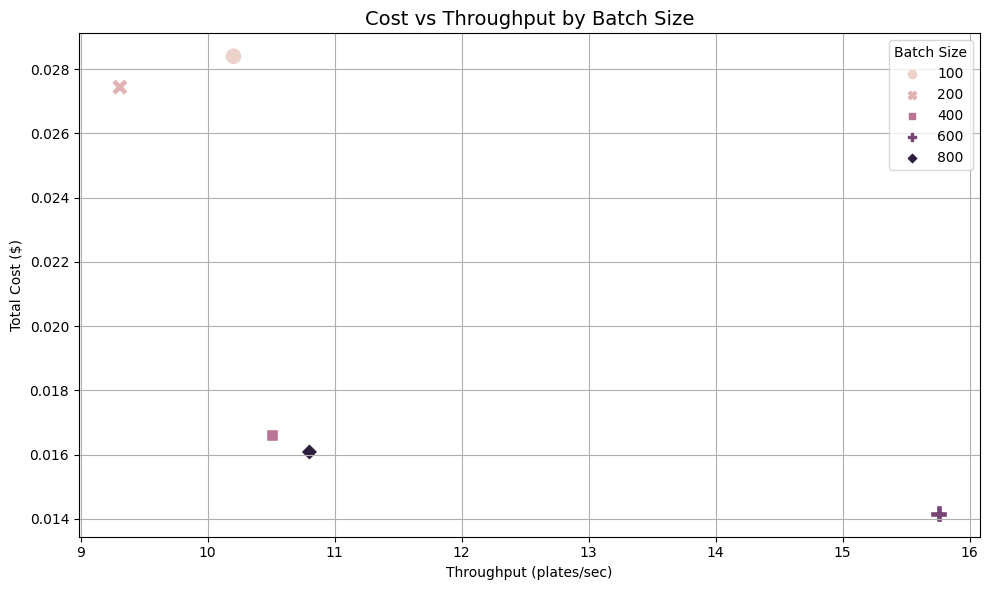

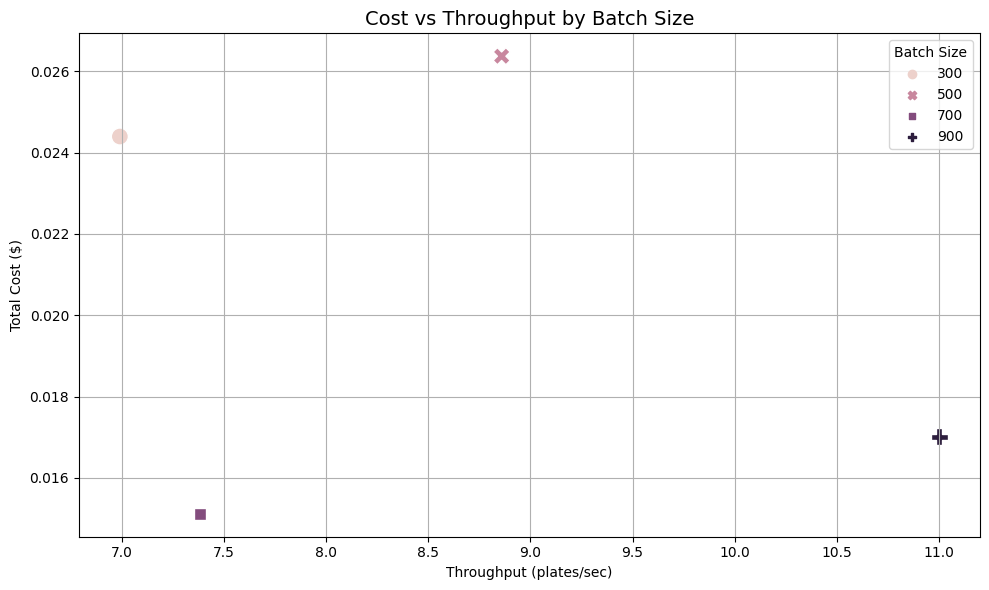

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure to have these at the top of your notebook or script:
# %matplotlib inline  (if using notebook)

# ---------- Plot 1: Cost vs Throughput ----------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary_df_even, x="throughput", y="cost", hue="batch_size", style="batch_size", s=150)
plt.title("Cost vs Throughput by Batch Size", fontsize=14)
plt.xlabel("Throughput (plates/sec)")
plt.ylabel("Total Cost ($)")
plt.grid(True)
plt.legend(title="Batch Size")
plt.tight_layout()
plt.show()


# ---------- Plot 1: Cost vs Throughput ----------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary_df_odd, x="throughput", y="cost", hue="batch_size", style="batch_size", s=150)
plt.title("Cost vs Throughput by Batch Size", fontsize=14)
plt.xlabel("Throughput (plates/sec)")
plt.ylabel("Total Cost ($)")
plt.grid(True)
plt.legend(title="Batch Size")
plt.tight_layout()
plt.show()



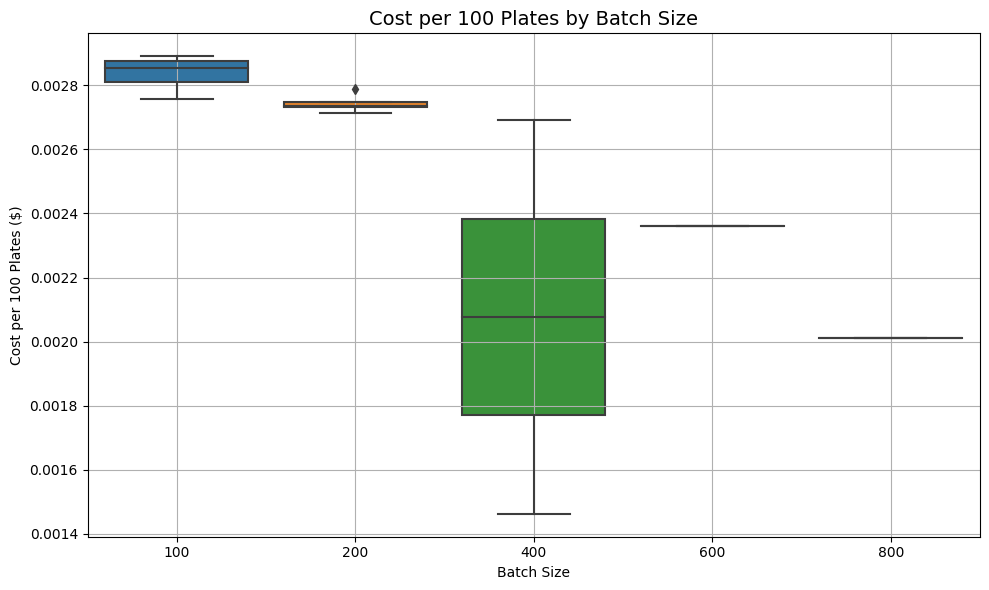

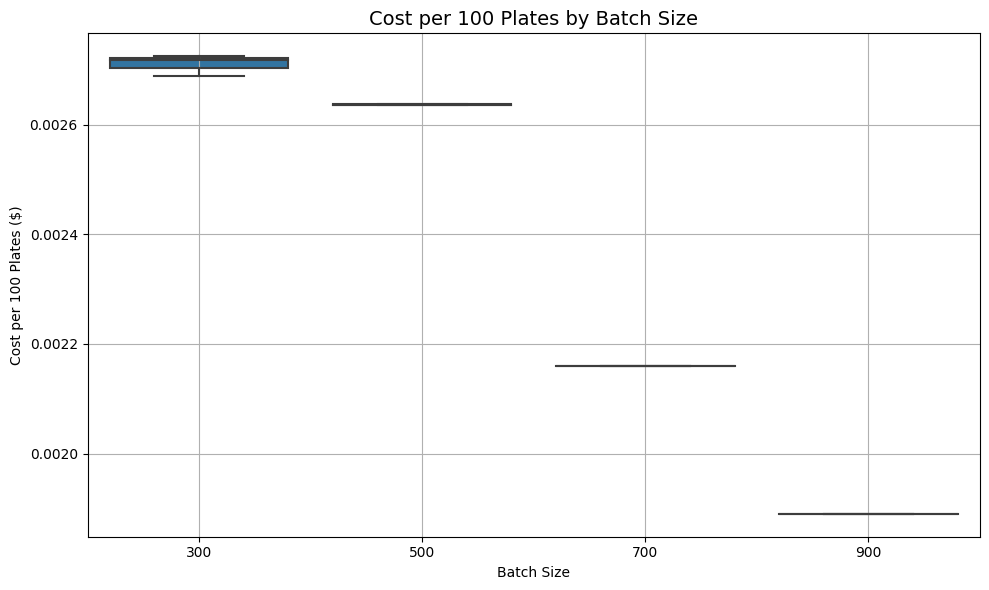

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt


# ---------- Plot 2: Cost per 100 Plates ----------
detailed_df_even["cost_per_100_plates"] = (detailed_df_even["total_cost"] / detailed_df_even["plates_processed"]) * 100
plt.figure(figsize=(10, 6))
sns.boxplot(data=detailed_df_even, x="batch_size", y="cost_per_100_plates")
plt.title("Cost per 100 Plates by Batch Size", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Cost per 100 Plates ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- Plot 2: Cost per 100 Plates ----------
detailed_df_odd["cost_per_100_plates"] = (detailed_df_odd["total_cost"] / detailed_df_odd["plates_processed"]) * 100
plt.figure(figsize=(10, 6))
sns.boxplot(data=detailed_df_odd, x="batch_size", y="cost_per_100_plates")
plt.title("Cost per 100 Plates by Batch Size", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Cost per 100 Plates ($)")
plt.grid(True)
plt.tight_layout()
plt.show()


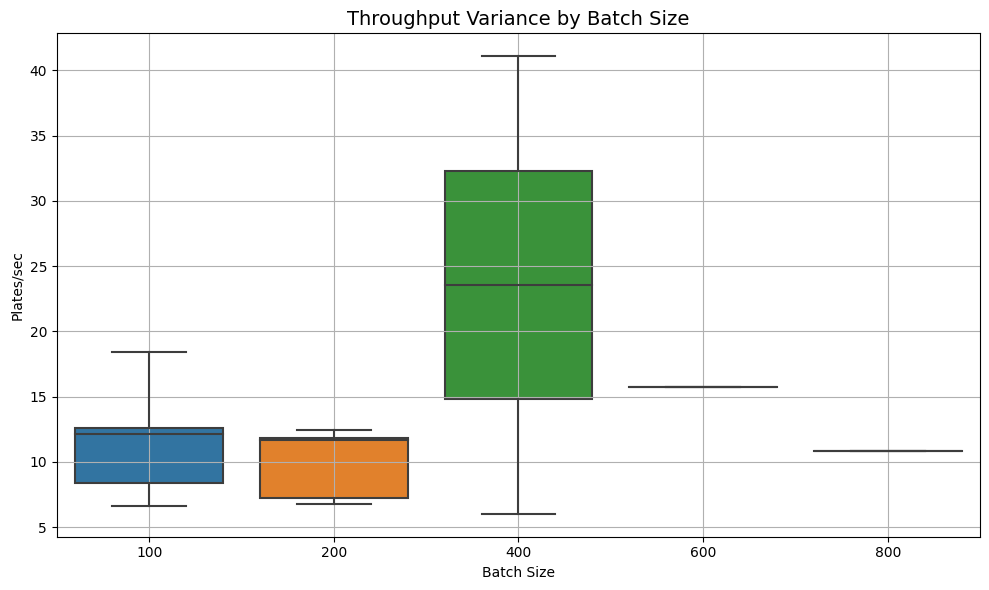

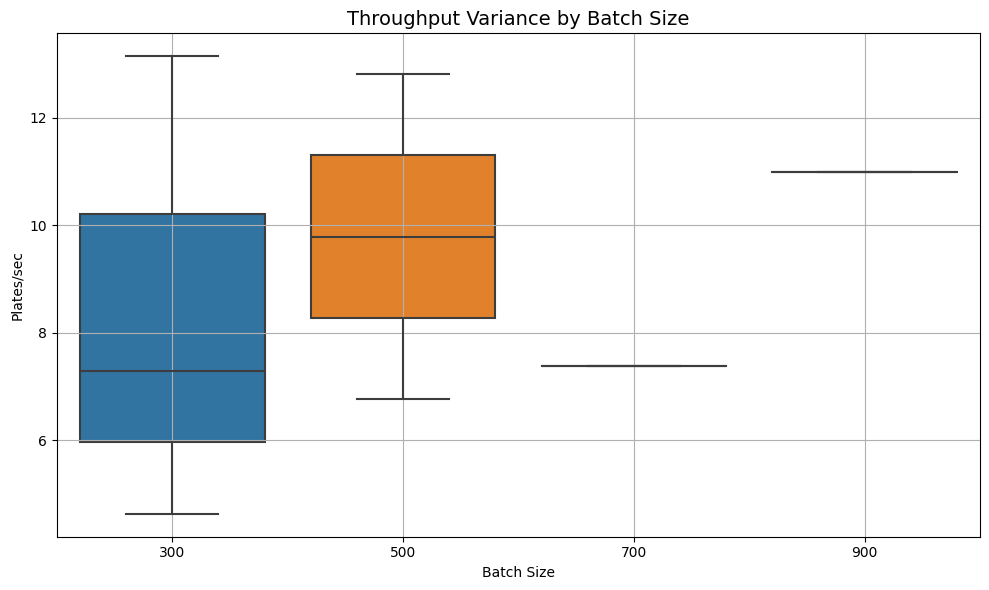

In [0]:

# ---------- Plot 3: Throughput Variance ----------
plt.figure(figsize=(10, 6))
sns.boxplot(data=detailed_df_even, x="batch_size", y="plates_per_sec")
plt.title("Throughput Variance by Batch Size", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Plates/sec")
plt.grid(True)
plt.tight_layout()
plt.show()
# ---------- Plot 3: Throughput Variance ----------
plt.figure(figsize=(10, 6))
sns.boxplot(data=detailed_df_odd, x="batch_size", y="plates_per_sec")
plt.title("Throughput Variance by Batch Size", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Plates/sec")
plt.grid(True)
plt.tight_layout()
plt.show()


In [0]:
# Step 1: Concatenate both DataFrames
detailed_df = pd.concat([detailed_df_odd, detailed_df_even], ignore_index=True)
summary_df = pd.concat([summary_df_odd, summary_df_even], ignore_index=True)


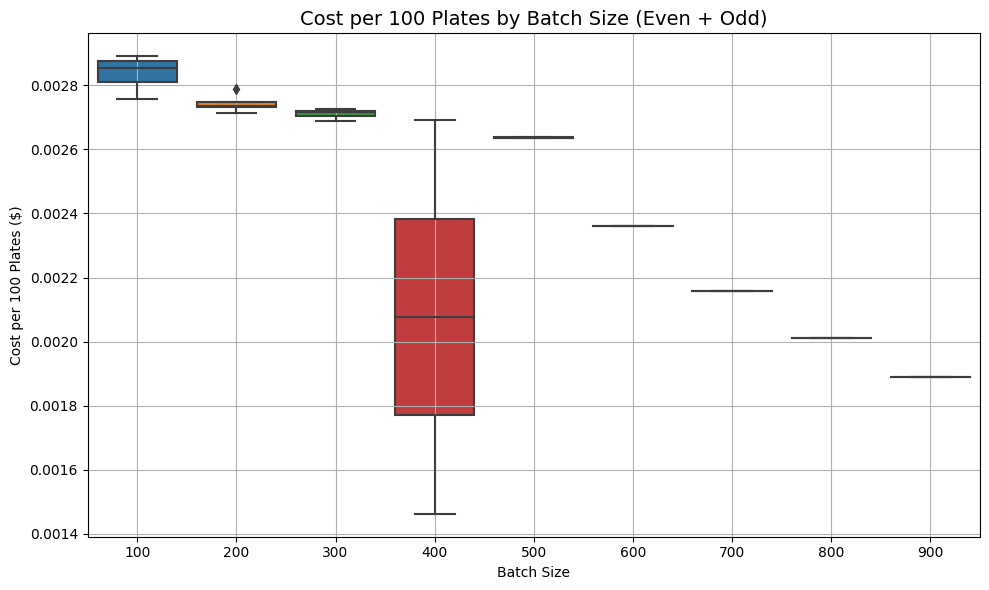

In [0]:



# ---------- Plot 1: Cost per 100 Plates ----------

detailed_df["cost_per_100_plates"] = (detailed_df["total_cost"] / detailed_df["plates_processed"]) * 100

plt.figure(figsize=(10, 6))
sns.boxplot(data=detailed_df, x="batch_size", y="cost_per_100_plates")
plt.title("Cost per 100 Plates by Batch Size (Even + Odd)", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Cost per 100 Plates ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

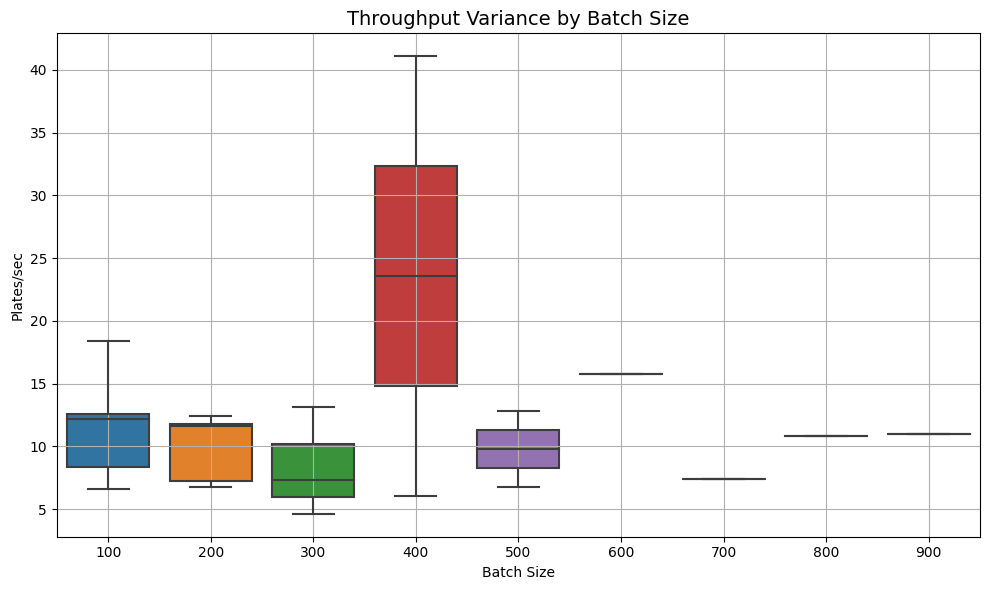

In [0]:
# ---------- Plot 2: Throughput Variance ----------
plt.figure(figsize=(10, 6))
sns.boxplot(data=detailed_df, x="batch_size", y="plates_per_sec")
plt.title("Throughput Variance by Batch Size", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Plates/sec")
plt.grid(True)
plt.tight_layout()
plt.show()

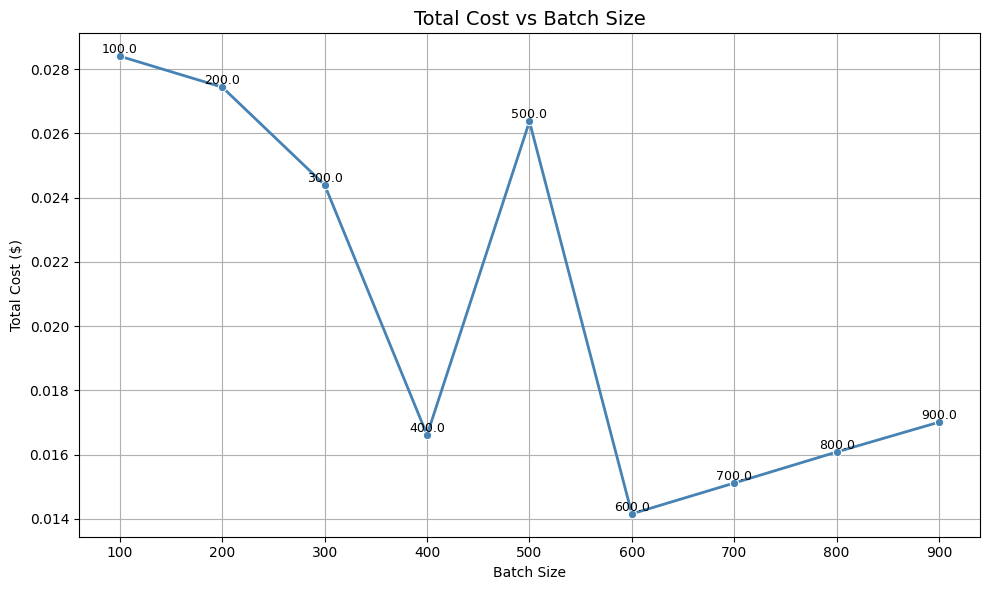

In [0]:
# 1. Sort by batch_size
summary_df_sorted = summary_df.sort_values(by="batch_size")

# 2. Line plot with markers
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=summary_df_sorted,
    x="batch_size",
    y="cost",
    marker="o",
    linewidth=2,
    color='steelblue'
)

# 3. Add value labels for each point (optional, but helpful)
for i, row in summary_df_sorted.iterrows():
    plt.text(row['batch_size'], row['cost'] + 0.0001, f"{row['batch_size']}", ha='center', fontsize=9)

# 4. Customize
plt.title("Total Cost vs Batch Size", fontsize=14)
plt.xlabel("Batch Size")
plt.ylabel("Total Cost ($)")
plt.grid(True)
plt.xticks(summary_df_sorted["batch_size"])  # ensure all batch sizes are shown
plt.tight_layout()
plt.show()
